In [36]:
# Imports
import os
import numpy as np
import pandas as pd
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import hdbscan
import collections

In [9]:
# 1. Set seed for reproducibility
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

# 2. Define file paths and variables
dataset_path    = "../Datasets/Merged_Dataset.csv"
target_variable = "Alzheimer.s.Diagnosis"

# 3. Create output directory if it doesn’t exist
outdir = "../All CSV Reports/PCA and Clustering"
os.makedirs(outdir, exist_ok=True)

In [ ]:
# One-hot encode all categorical columns except the target and any exclusions
def one_hot_encode_all_levels(df, target_col, exclude_cols=[]):
    # 1) Identify which columns to encode (object or category, except target/excluded)
    cols_to_encode = [
        col for col in df.select_dtypes(include=['object', 'category']).columns
        if col not in [target_col] + exclude_cols
    ]
    # 2) Use pandas.get_dummies to create dummy variables (for all levels)
    df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)
    return df_encoded

#usage:
exclude_variable = ['Any', 'Columns', 'To', 'Exclude']
df = pd.read_csv(dataset_path)
df_encoded = one_hot_encode_all_levels(df, target_variable, exclude_variable)
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7149 entries, 0 to 7148
Data columns (total 92 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       7149 non-null   int64  
 1   BMI                                       7149 non-null   float64
 2   Alcohol.Consumption.NUM                   7149 non-null   float64
 3   Physical.Activity.NUM                     7149 non-null   float64
 4   Diet.Quality.NUM                          7149 non-null   float64
 5   Sleep.Quality.NUM                         7149 non-null   float64
 6   SystolicBP                                7149 non-null   int64  
 7   DiastolicBP                               7149 non-null   int64  
 8   CholesterolTotal                          7149 non-null   float64
 9   CholesterolLDL                            7149 non-null   float64
 10  CholesterolHDL                      

In [12]:
def run_pca(df, target_col, exclude_cols=[]):
    # 1) Exclude target and any additional exclusions
    cols_to_exclude = [target_col] + exclude_cols
    num_df = df.drop(columns=cols_to_exclude, errors='ignore')
    
    # 2) Keep only numeric columns
    num_df = num_df.select_dtypes(include=[np.number])
    
    # 3) Scale (standardize) the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(num_df)
    
    # 4) Run PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # 5) Print explained variance for each principal component
    variance = pca.explained_variance_ratio_
    print("Explained variance by component:")
    print(variance)
    
    return pca, X_pca, scaler

# Usage:
pca_result, pca_scores, scaler = run_pca(df_encoded, target_variable, exclude_variable)


Explained variance by component:
[0.0718376  0.0683431  0.06654868 0.06617494 0.06486037 0.06413051
 0.06355966 0.06281168 0.06150022 0.0610047  0.06075331 0.06026102
 0.05889194 0.05832623 0.05694703 0.054049  ]


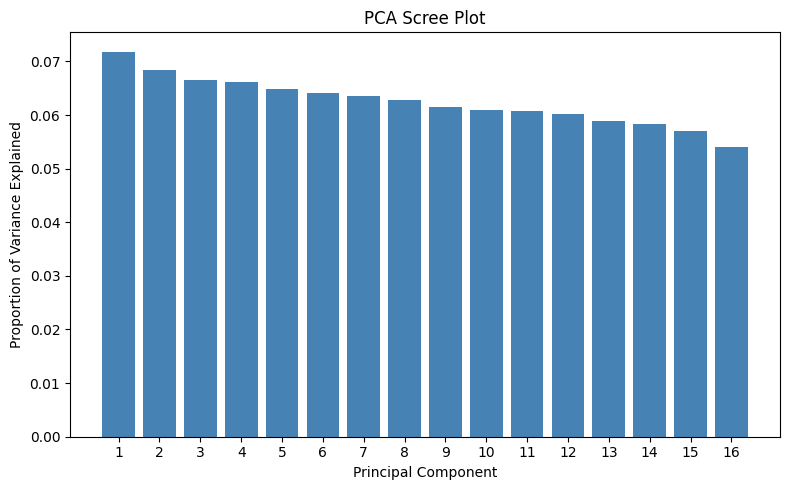

In [14]:
def plot_pca_scree(pca):
    # 1) Get variance explained by each component
    var_explained = pca.explained_variance_ratio_
    pcs = np.arange(1, len(var_explained) + 1)
    
    # 2) Make the scree plot
    plt.figure(figsize=(8, 5))
    plt.bar(pcs, var_explained, color='steelblue')
    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Variance Explained')
    plt.title('PCA Scree Plot')
    plt.xticks(pcs)
    plt.tight_layout()
    plt.show()

# Usage:
plot_pca_scree(pca_result)


Explained variance per PC:
[0.0718376  0.0683431  0.06654868 0.06617494 0.06486037 0.06413051
 0.06355966 0.06281168 0.06150022 0.0610047  0.06075331 0.06026102
 0.05889194 0.05832623 0.05694703 0.054049  ]
Cumulative explained variance:
[0.0718376  0.1401807  0.20672938 0.27290432 0.33776469 0.4018952
 0.46545486 0.52826654 0.58976676 0.65077146 0.71152477 0.77178579
 0.83067773 0.88900397 0.945951   1.        ]


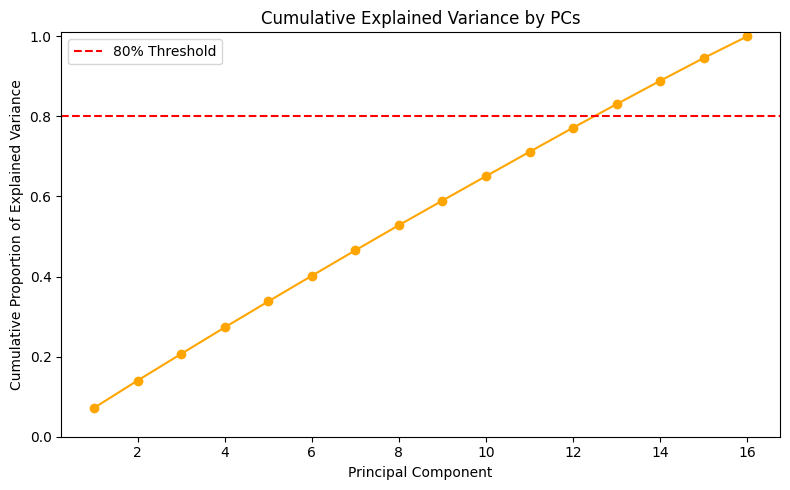

In [16]:
def run_pca_analysis(df, target_col, exclude_cols=[]):
    # 1) Select only numeric columns, drop target and exclusions
    cols_to_exclude = [target_col] + exclude_cols
    num_df = df.drop(columns=cols_to_exclude, errors='ignore').select_dtypes(include=[np.number])
    
    # 2) Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(num_df)
    
    # 3) Fit PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # 4) Print explained variance
    print("Explained variance per PC:")
    print(pca.explained_variance_ratio_)
    print("Cumulative explained variance:")
    print(np.cumsum(pca.explained_variance_ratio_))
    
    # 5) Plot cumulative explained variance (scree-style, but cumulative)
    plt.figure(figsize=(8, 5))
    plt.plot(
        np.arange(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_),
        marker='o', color='orange'
    )
    plt.axhline(0.8, color='red', linestyle='dashed', label='80% Threshold')
    plt.ylim(0, 1.01)
    plt.xlabel('Principal Component')
    plt.ylabel('Cumulative Proportion of Explained Variance')
    plt.title('Cumulative Explained Variance by PCs')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 6) Return PCA object (and optionally scaler and scores)
    return pca, X_pca, scaler

# Example usage:
pca_result, X_pca, scaler = run_pca_analysis(df_encoded, target_variable, exclude_variable)


In [19]:
def stratified_sample_by_target(df, target_col, sizes, remove_id=True, id_col="ID"):
    # 1) Ensure target is treated as a categorical (no-op in pandas, but for consistency)
    df[target_col] = df[target_col].astype('category')
    
    # 2) Get class labels
    classes = df[target_col].cat.categories
    n_classes = len(classes)
    
    # 3) Prepare size vector for each class
    if isinstance(sizes, int):
        size_vec = [sizes] * n_classes
    elif hasattr(sizes, '__len__') and len(sizes) == n_classes:
        size_vec = list(sizes)
    else:
        raise ValueError(f"`sizes` must be either length 1 or equal to the number of classes ({n_classes}).")
    
    # 4) Perform stratified sampling without replacement
    sampled_frames = []
    for class_label, class_size in zip(classes, size_vec):
        class_subset = df[df[target_col] == class_label]
        sampled = resample(
            class_subset,
            replace=False,
            n_samples=class_size,
            random_state=SEED
        )
        sampled_frames.append(sampled)
    sampled_df = pd.concat(sampled_frames, ignore_index=True)
    
    # 5) Optionally drop the ID column
    if remove_id and id_col in sampled_df.columns:
        sampled_df = sampled_df.drop(columns=[id_col])
        
    return sampled_df

# Example usage:
df_ready = stratified_sample_by_target(df_encoded, target_variable, 3260)

# Check resulting class proportions (should be balanced)
print(df_ready[target_variable].value_counts(normalize=True))


Alzheimer.s.Diagnosis
No     0.5
Yes    0.5
Name: proportion, dtype: float64


K-Means

Explained variance by component:
[0.07187227 0.06872962 0.06699411 0.06565036 0.06490662 0.064227
 0.06307462 0.06256896 0.06140598 0.0612269  0.06057656 0.05988325
 0.05921059 0.05834393 0.0570468  0.05428245]
Retaining 15 PCs (94.6% variance)


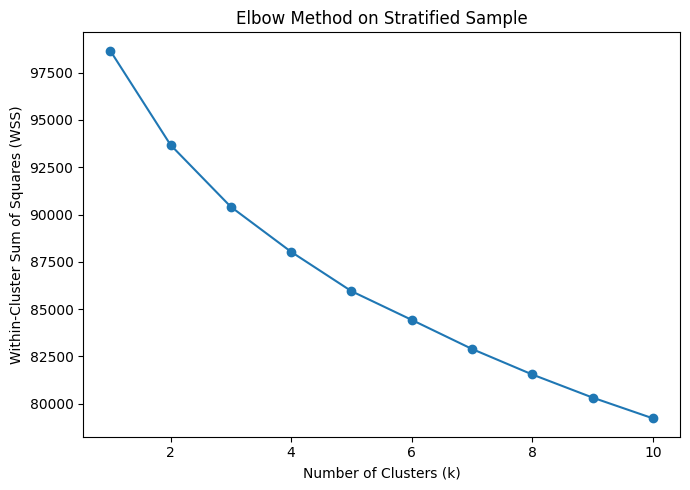

   k       ASW
0  2  0.050126
1  3  0.044088
2  4  0.042434
3  5  0.042235
4  6  0.041704
5  7  0.042692
6  8  0.042867
7  9  0.043082


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import pandas as pd

# --- Run PCA on the stratified sample ---
pca_result_ready, X_pca_ready, _ = run_pca(df_ready, target_variable, exclude_variable)

# --- Decide how many PCs to keep to reach 90% variance ---
explained_variance = pca_result_ready.explained_variance_ratio_
cum_var = np.cumsum(explained_variance)
threshold = 0.90
n_pcs = np.argmax(cum_var >= threshold) + 1
print(f"Retaining {n_pcs} PCs ({cum_var[n_pcs-1]*100:.1f}% variance)")

# --- Use the top principal component scores ---
pca_scores_ready = X_pca_ready[:, :n_pcs]

# --- Elbow method (WSS plot) ---
wss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED)
    km.fit(pca_scores_ready)
    wss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, wss, marker='o')
plt.title("Elbow Method on Stratified Sample")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WSS)")
plt.tight_layout()
plt.show()

# --- Silhouette Analysis ---
k_values = range(2, 10)
kmeans_results = {}
sil_widths = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED)
    labels = km.fit_predict(pca_scores_ready)
    sil_score = silhouette_score(pca_scores_ready, labels)
    sil_widths.append(sil_score)
    kmeans_results[f'k{k}'] = km
    
    # Optional: plot silhouettes using sklearn’s plot (requires scikit-learn ≥1.3)
    # silhouette_plot = silhouette_samples(pca_scores_ready, labels)
    # plot_silhouette(silhouette_plot, labels)  # custom function if needed

# --- Compare average silhouette widths ---
sil_df = pd.DataFrame({
    'k': list(k_values),
    'ASW': sil_widths
})
print(sil_df)


Best k by average silhouette: 2


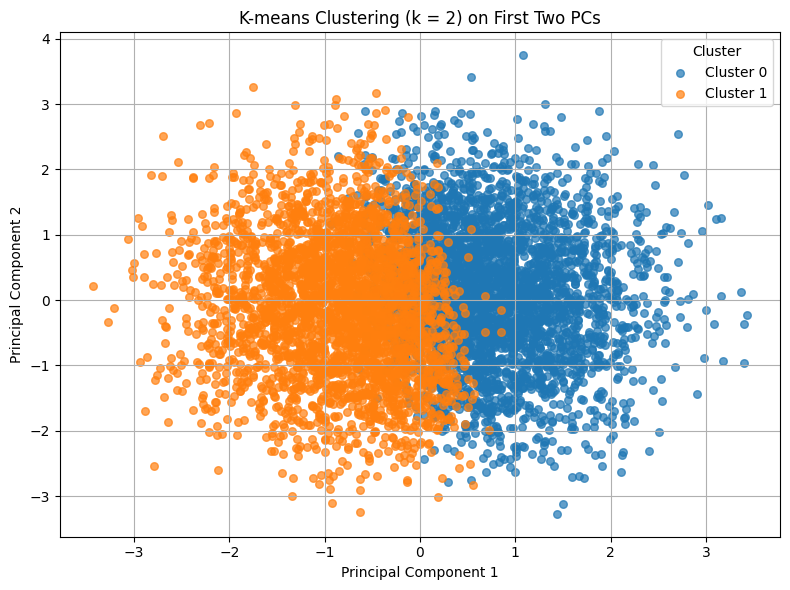

In [22]:
# 1. Pick the best k based on silhouette analysis
best_k = sil_df.loc[sil_df['ASW'].idxmax(), 'k']
print(f"Best k by average silhouette: {best_k}")

# 2. Re-run KMeans using best k on top PCA scores
km_best = KMeans(n_clusters=best_k, random_state=SEED)
labels_best = km_best.fit_predict(pca_scores_ready)

# 3. Prepare DataFrame for plotting first two PCs
plot_df = pd.DataFrame({
    'PC1': pca_scores_ready[:, 0],
    'PC2': pca_scores_ready[:, 1],
    'cluster': labels_best.astype(str)  # Use str to mimic ggplot color by factor
})

# 4. Scatter plot the clusters
plt.figure(figsize=(8, 6))
for cluster_id in sorted(plot_df['cluster'].unique()):
    subset = plot_df[plot_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster_id}', alpha=0.7, s=30)

plt.title(f"K-means Clustering (k = {best_k}) on First Two PCs")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


    k       ASW
0   2  0.031556
1   3  0.026575
2   4  0.021638
3   5  0.018401
4   6  0.021459
5   7  0.020440
6   8  0.020614
7   9  0.016964
8  10  0.016454


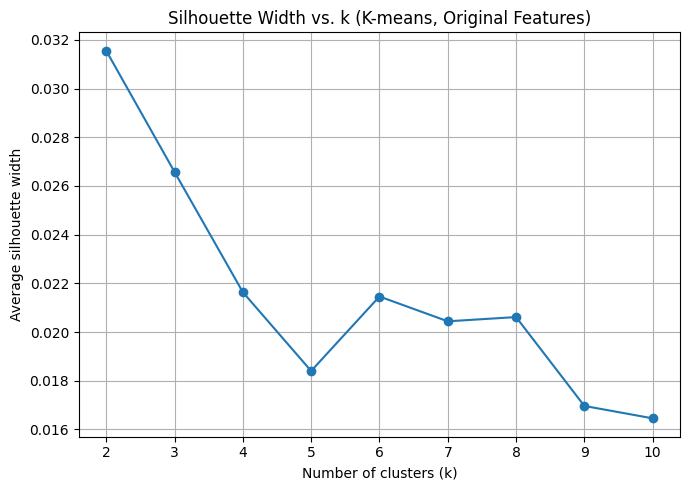

Best k by average silhouette width (k-means): 2


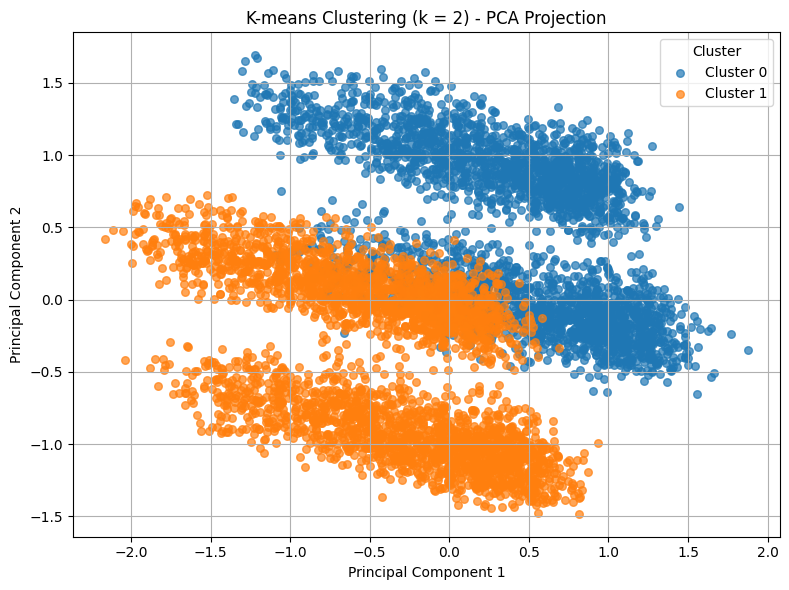

In [27]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Remove target/excluded columns and scale features
cols_to_remove = [target_variable] + exclude_variable
orig_clust_df = df_ready.drop(columns=cols_to_remove, errors='ignore')

scaler_minmax = MinMaxScaler()
orig_clust_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(orig_clust_df),
    columns=orig_clust_df.columns
)

# 2. K-means silhouette analysis for k = 2 to 10
sil_widths_km = []
k_values_km = range(2, 11)
kmeans_results = {}

for k in k_values_km:
    km = KMeans(n_clusters=k, random_state=SEED)
    labels = km.fit_predict(orig_clust_minmax)
    sil_score = silhouette_score(orig_clust_minmax, labels)
    sil_widths_km.append(sil_score)
    kmeans_results[k] = km

# 3. Silhouette summary table
sil_df_km = pd.DataFrame({
    "k": list(k_values_km),
    "ASW": sil_widths_km
})
print(sil_df_km)

# 4. Plot average silhouette width vs k
plt.figure(figsize=(7, 5))
plt.plot(sil_df_km['k'], sil_df_km['ASW'], marker='o')
plt.title("Silhouette Width vs. k (K-means, Original Features)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette width")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Select best k and fit final K-means
best_k_km = sil_df_km.loc[sil_df_km['ASW'].idxmax(), 'k']
print(f"Best k by average silhouette width (k-means): {best_k_km}")

km_best = KMeans(n_clusters=best_k_km, random_state=SEED)
labels_best_km = km_best.fit_predict(orig_clust_minmax)

# 6. Project scaled data to 2D PCA space for plotting
pca_plot = PCA(n_components=2)
orig_clust_pca2D = pca_plot.fit_transform(orig_clust_minmax)

# 7. Plot clusters using PCA projection
km_plot_df = pd.DataFrame({
    "PC1": orig_clust_pca2D[:, 0],
    "PC2": orig_clust_pca2D[:, 1],
    "cluster": labels_best_km.astype(str)
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(km_plot_df['cluster'].unique()):
    subset = km_plot_df[km_plot_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster_id}', alpha=0.7, s=30)

plt.title(f"K-means Clustering (k = {best_k_km}) - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


Hierarchical Clustering

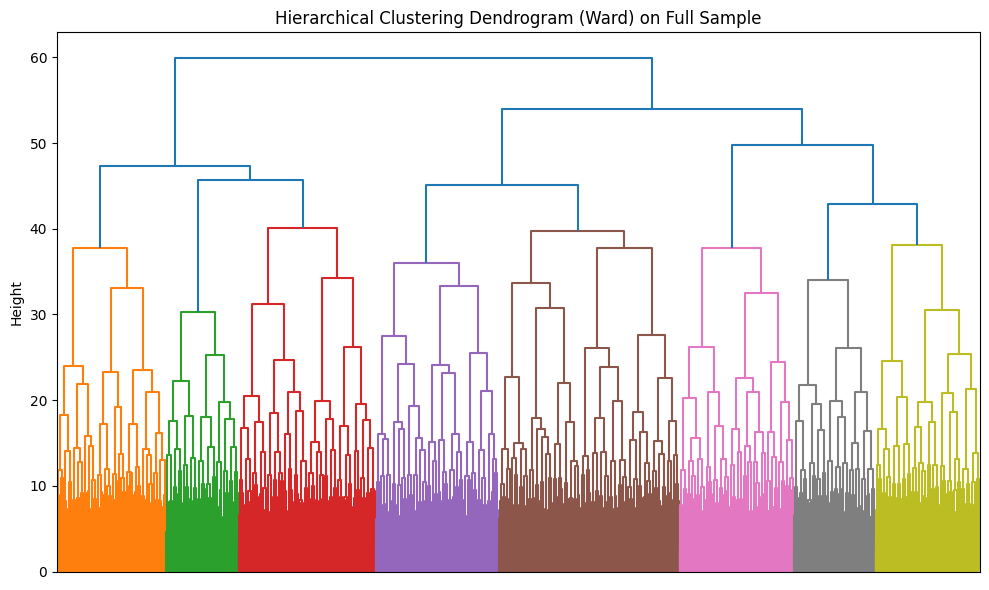

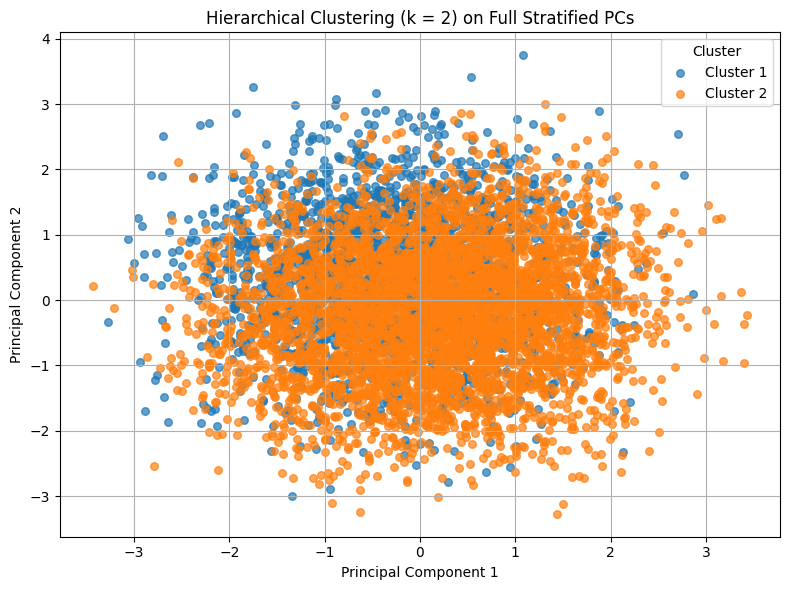

In [29]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Compute Euclidean distance matrix on PCA scores
# (assuming pca_scores_ready already contains top-n PCs)
distance_matrix = pdist(pca_scores_ready, metric='euclidean')

# 2. Perform hierarchical clustering using Ward’s method
linkage_matrix = linkage(distance_matrix, method='ward')

# 3. Plot dendrogram (without labels)
plt.figure(figsize=(10, 6))
dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=None
)
plt.title("Hierarchical Clustering Dendrogram (Ward) on Full Sample")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

# 4. Cut the tree into `best_k` clusters
hc_clusters_full = fcluster(linkage_matrix, t=best_k, criterion='maxclust')

# 5. Prepare DataFrame for plotting first two PCs
hc_plot_df_full = pd.DataFrame({
    "PC1": pca_scores_ready[:, 0],
    "PC2": pca_scores_ready[:, 1],
    "cluster": hc_clusters_full.astype(str)
})

# 6. Scatter plot of clusters using first two PCs
plt.figure(figsize=(8, 6))
for cluster_id in sorted(hc_plot_df_full['cluster'].unique()):
    subset = hc_plot_df_full[hc_plot_df_full['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster_id}', alpha=0.7, s=30)

plt.title(f"Hierarchical Clustering (k = {best_k}) on Full Stratified PCs")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


    k       ASW
0   2  0.012703
1   3  0.008587
2   4  0.002747
3   5  0.000389
4   6 -0.001308
5   7 -0.002665
6   8 -0.003619
7   9 -0.005362
8  10 -0.005931


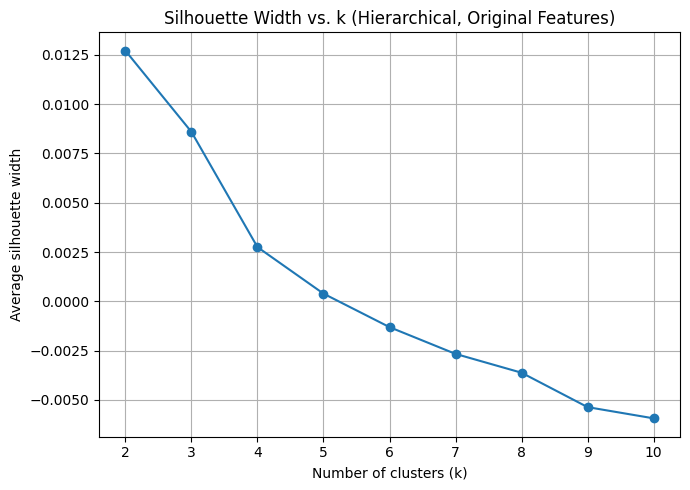

Best k by average silhouette width (hierarchical): 2


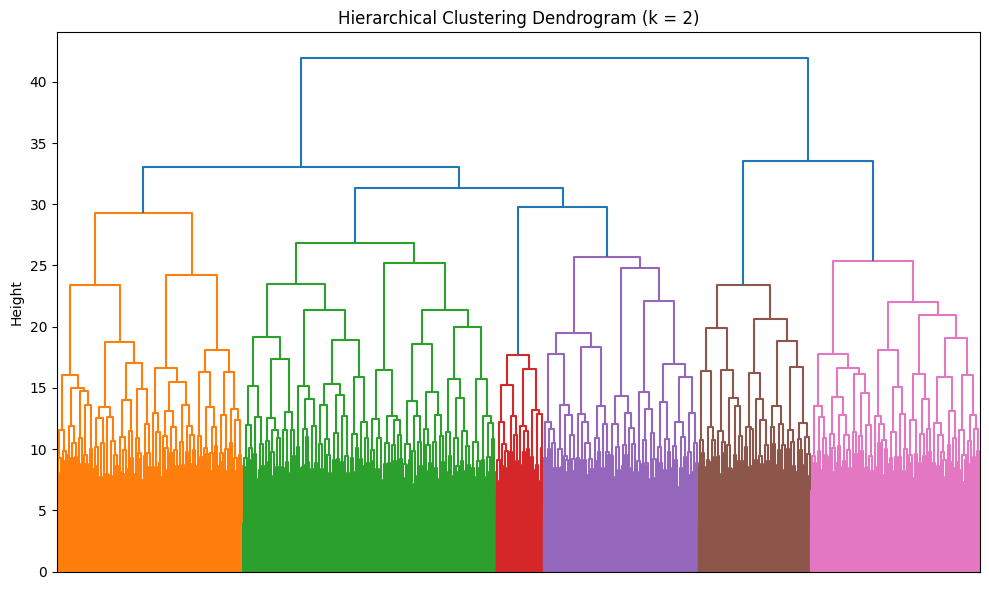

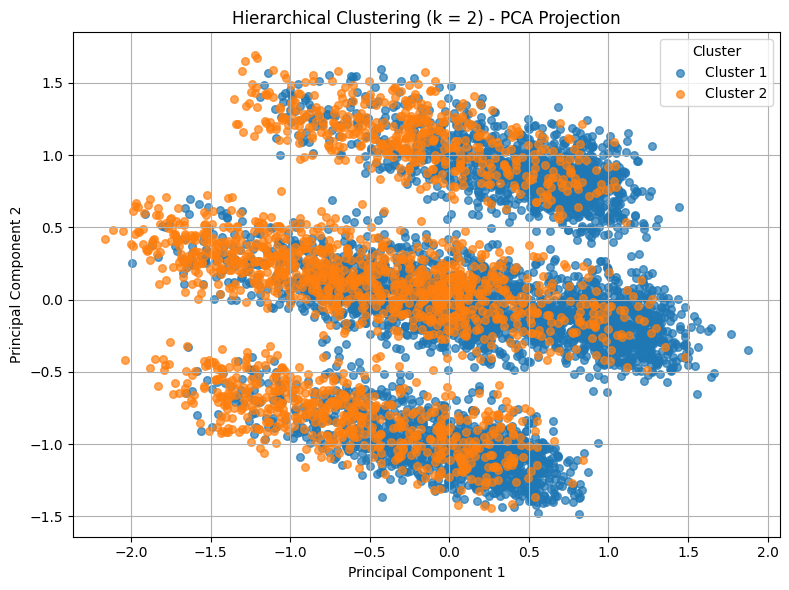

In [31]:
# 1. Drop target/excluded cols & scale the original features
cols_to_remove = [target_variable] + exclude_variable
orig_clust_df = df_ready.drop(columns=cols_to_remove, errors='ignore')

scaler_minmax = MinMaxScaler()
orig_clust_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(orig_clust_df),
    columns=orig_clust_df.columns
)

# 2. Compute distance matrix and hierarchical clustering (Ward)
hc_dist_orig = pdist(orig_clust_minmax, metric='euclidean')
hc_ward_orig = linkage(hc_dist_orig, method='ward')

# 3. Silhouette analysis for k = 2 to 10
sil_widths_hc = []
k_range = range(2, 11)
for k in k_range:
    clusters = fcluster(hc_ward_orig, t=k, criterion='maxclust')
    sil_score = silhouette_score(squareform(hc_dist_orig), clusters, metric='precomputed')
    sil_widths_hc.append(sil_score)

# 4. Silhouette summary + plot
sil_df_hc = pd.DataFrame({"k": list(k_range), "ASW": sil_widths_hc})
print(sil_df_hc)

plt.figure(figsize=(7, 5))
plt.plot(sil_df_hc['k'], sil_df_hc['ASW'], marker='o')
plt.title("Silhouette Width vs. k (Hierarchical, Original Features)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette width")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Select best k
best_k_hc = sil_df_hc.loc[sil_df_hc['ASW'].idxmax(), 'k']
print(f"Best k by average silhouette width (hierarchical): {best_k_hc}")

# 6. Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(hc_ward_orig, no_labels=True, color_threshold=None)
plt.title(f"Hierarchical Clustering Dendrogram (k = {best_k_hc})")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

# 7. Assign final cluster labels
hc_clusters_orig = fcluster(hc_ward_orig, t=best_k_hc, criterion='maxclust')

# 8. PCA for plotting only (project to 2D)
pca_plot = PCA(n_components=2)
clust_2d = pca_plot.fit_transform(orig_clust_minmax)

# 9. Plot clusters using PCA projection
hc_plot_df = pd.DataFrame({
    "PC1": clust_2d[:, 0],
    "PC2": clust_2d[:, 1],
    "cluster": hc_clusters_orig.astype(str)
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(hc_plot_df['cluster'].unique()):
    subset = hc_plot_df[hc_plot_df['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster_id}', alpha=0.7, s=30)

plt.title(f"Hierarchical Clustering (k = {best_k_hc}) - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


HDBSCAN Clustering

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 2 clusters and 6447 noise points.


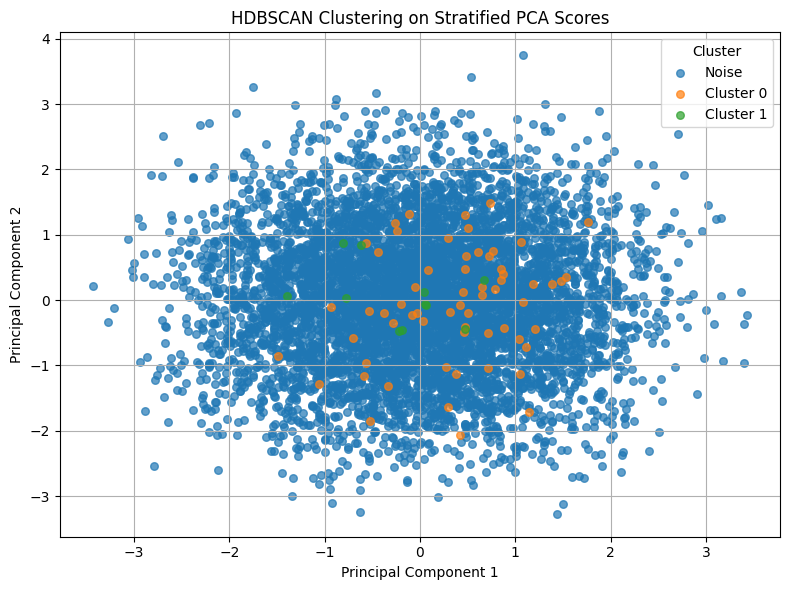

In [41]:
# 1. Run HDBSCAN clustering on PCA scores (e.g., pca_scores_ready from previous step)
hdb = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean', prediction_data=True)
hdb_labels = hdb.fit_predict(pca_scores_ready)

# 2. Print number of clusters and noise points
num_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
num_noise = sum(hdb_labels == -1)
print(f"HDBSCAN found {num_clusters} clusters and {num_noise} noise points.")

# 3. Prepare DataFrame for plotting (using first two PCs)
hdb_plot_df = pd.DataFrame({
    "PC1": pca_scores_ready[:, 0],
    "PC2": pca_scores_ready[:, 1],
    "cluster": hdb_labels.astype(str)
})

# 4. Scatter plot of clusters using PCA projection
plt.figure(figsize=(8, 6))
for cluster_id in sorted(hdb_plot_df['cluster'].unique(), key=lambda x: int(x) if x != '-1' else -1):
    subset = hdb_plot_df[hdb_plot_df['cluster'] == cluster_id]
    label = "Noise" if cluster_id == "-1" else f"Cluster {cluster_id}"
    plt.scatter(subset["PC1"], subset["PC2"], label=label, alpha=0.7, s=30)

plt.title("HDBSCAN Clustering on Stratified PCA Scores")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 2 clusters and 6242 noise points.
Cluster label counts (incl. noise): Counter({np.int64(-1): 6242, np.int64(0): 262, np.int64(1): 16})


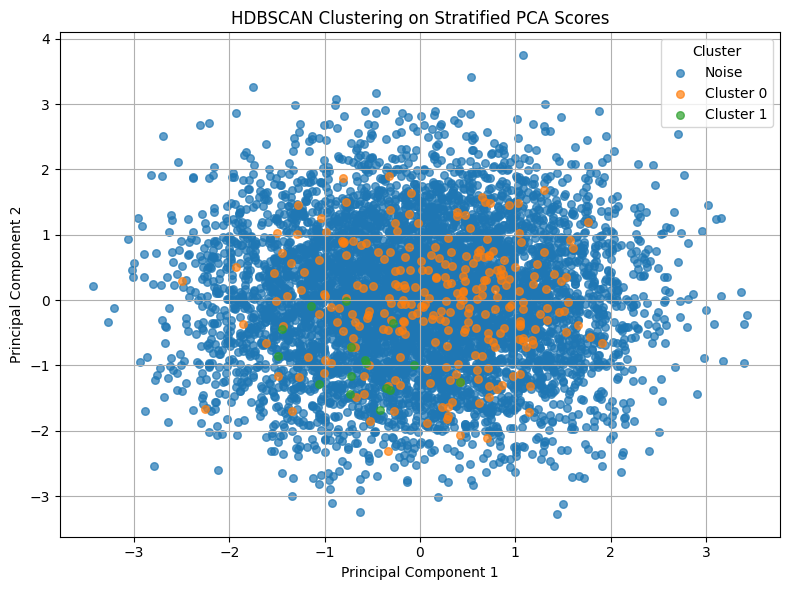

In [42]:
# 1. Run HDBSCAN on PCA scores (top components from run_pca)
hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,      # feel free to tune this up/down
    min_samples=5,            # slightly more tolerant to structure
    metric='euclidean',
    prediction_data=True
)
hdb_labels = hdb.fit_predict(pca_scores_ready)

# 2. Cluster summary
num_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
num_noise = np.sum(hdb_labels == -1)
print(f"HDBSCAN found {num_clusters} clusters and {num_noise} noise points.")
print("Cluster label counts (incl. noise):", collections.Counter(hdb_labels))

# 3. Prepare DataFrame for plotting (2D PCA projection)
hdb_plot_df = pd.DataFrame({
    "PC1": pca_scores_ready[:, 0],
    "PC2": pca_scores_ready[:, 1],
    "cluster": hdb_labels.astype(str)
})

# 4. Cluster scatter plot
plt.figure(figsize=(8, 6))
for cluster_id in sorted(hdb_plot_df['cluster'].unique(), key=lambda x: int(x) if x != '-1' else -1):
    subset = hdb_plot_df[hdb_plot_df['cluster'] == cluster_id]
    label = "Noise" if cluster_id == "-1" else f"Cluster {cluster_id}"
    plt.scatter(subset["PC1"], subset["PC2"],
                label=label, alpha=0.7, s=30)

plt.title("HDBSCAN Clustering on Stratified PCA Scores")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

Without pca

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 3 clusters and 6472 noise points.
Cluster label counts (incl. noise): Counter({np.int64(-1): 6472, np.int64(0): 22, np.int64(1): 14, np.int64(2): 12})


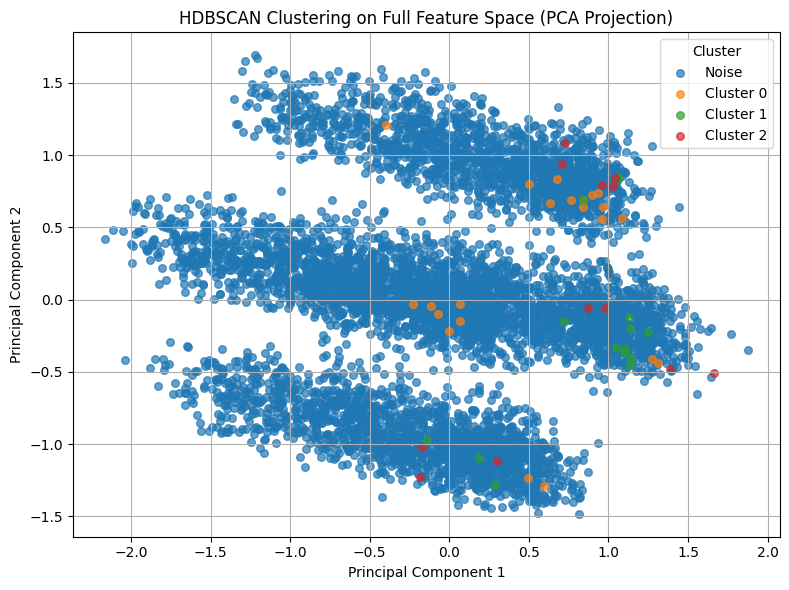

In [43]:
# 1. Prepare min-max scaled feature data (excluding target and exclusions)
cols_to_remove = [target_variable] + exclude_variable
clust_df = df_ready.drop(columns=cols_to_remove, errors='ignore')

scaler = MinMaxScaler()
clust_scaled = pd.DataFrame(
    scaler.fit_transform(clust_df),
    columns=clust_df.columns
)

# 2. Run HDBSCAN on high-dimensional scaled data
hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,         # adjust if needed
    min_samples=5,
    metric='euclidean',
    prediction_data=True
)
hdb_labels = hdb.fit_predict(clust_scaled)

# 3. Summary of clusters
num_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
num_noise = np.sum(hdb_labels == -1)
print(f"HDBSCAN found {num_clusters} clusters and {num_noise} noise points.")
print("Cluster label counts (incl. noise):", collections.Counter(hdb_labels))

# 4. PCA for 2D visualization
pca_proj = PCA(n_components=2)
clust_2d = pca_proj.fit_transform(clust_scaled)

# 5. Prepare DataFrame for plotting
hdb_plot_df = pd.DataFrame({
    "PC1": clust_2d[:, 0],
    "PC2": clust_2d[:, 1],
    "cluster": hdb_labels.astype(str)
})

# 6. Scatter plot of clusters (projected in 2D)
plt.figure(figsize=(8, 6))
for cluster_id in sorted(hdb_plot_df['cluster'].unique(), key=lambda x: int(x) if x != '-1' else -1):
    subset = hdb_plot_df[hdb_plot_df['cluster'] == cluster_id]
    label = "Noise" if cluster_id == "-1" else f"Cluster {cluster_id}"
    plt.scatter(subset["PC1"], subset["PC2"],
                label=label, alpha=0.7, s=30)

plt.title("HDBSCAN Clustering on Full Feature Space (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()